In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
Features = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
  "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH", "Hour", "Month"]
TARGETS= ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
LEARNING_RATE=0.0001

In [ ]:
df= pd.read_csv("https://raw.githubusercontent.com/naimdotcom/Machine-Learning/main/data/AirQualityUCI - AirQualityUCI.csv")

In [ ]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [ ]:
df = df.drop(columns=["NMHC(GT)"])

In [ ]:
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour
df["Month"] = pd.to_datetime(df["Date"]).dt.month
df = df.drop(columns=["Date", "Time"])

In [ ]:
df = df.replace(-200, np.nan)
df.isnull().sum()
df = df.dropna()
print(df.shape)

(6941, 14)


In [ ]:
df.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour,Month
count,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.00000
mean,2.182467,1119.913269,10.554488,958.543005,250.671949,816.893387,113.874082,1452.648898,1057.756519,17.755323,48.881905,0.985573,12.020170,6.02723
std,1.441158,218.733754,7.465226,264.055002,208.611371,251.897200,47.475017,353.301576,406.509957,8.844909,17.433193,0.401097,6.813924,3.48971
min,0.100000,647.000000,0.200000,390.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,0.000000,1.00000
25%,1.100000,956.000000,4.900000,760.000000,103.000000,642.000000,79.000000,1207.000000,760.000000,11.200000,35.300000,0.694100,7.000000,3.00000
50%,1.900000,1085.000000,8.800000,931.000000,186.000000,786.000000,110.000000,1457.000000,1006.000000,16.800000,49.200000,0.953900,12.000000,6.00000
75%,2.900000,1254.000000,14.600000,1135.000000,335.000000,947.000000,142.000000,1683.000000,1322.000000,23.700000,62.200000,1.251600,18.000000,9.00000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,333.000000,2775.000000,2523.000000,44.600000,88.700000,2.180600,23.000000,12.00000


In [ ]:

X = df[Features].values   # .values converts pandas → numpy array
Y = df[TARGETS].values    # shape will be (n_rows, 4)
print(X.shape, Y.shape)

(6941, 10) (6941, 4)


In [ ]:
x_train, x_test, y_train, y_test =train_test_split(X,Y, test_size=0.20, random_state=42)

In [ ]:
train_mean = x_train.mean(axis=0)
train_std  = x_train.std(axis=0)

x_train = (x_train - train_mean) / train_std
x_test  = (x_test  - train_mean) / train_std

In [ ]:
print(x_train.mean(axis=0))   # should be ~0 for all features
print(x_train.std(axis=0))    # should be ~1 for all features
print("X_train mean:", x_train.mean(axis=0))
print("X_train std: ", x_train.std(axis=0))
print("X_test mean: ", x_test.mean(axis=0))


[ 8.38266376e-17 -4.43529299e-17 -2.24664187e-16  2.84314679e-16
  2.49160283e-17 -6.94634272e-16  1.42281120e-14  1.75848344e-15
 -9.20253307e-17 -2.53859533e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
X_train mean: [ 8.38266376e-17 -4.43529299e-17 -2.24664187e-16  2.84314679e-16
  2.49160283e-17 -6.94634272e-16  1.42281120e-14  1.75848344e-15
 -9.20253307e-17 -2.53859533e-16]
X_train std:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
X_test mean:  [ 0.02010056  0.02761584 -0.01965752  0.04618955  0.00531344  0.02943653
  0.00158551  0.0380235   0.04370239 -0.00664709]


In [ ]:
def regression(x,w,b):
  return np.dot(x,w) + b

In [ ]:
def compute_cost(x,y,w,b):
  m=x.shape[0]
  fw_b = regression(x,w,b)
  cost = np.sum((fw_b-y)**2)/(2*m)
  return cost

In [ ]:
def compute_gradient(x,y,w,b):
  m=x.shape[0]
  fw_b = regression(x,w,b)
  learning_error = fw_b-y
  dj_w = np.dot(x.T, learning_error)/m
  dj_b = np.sum(learning_error, axis=0)/m
  return dj_w, dj_b

In [ ]:
def gradient_descent(x,y, alp=LEARNING_RATE, iteration=1000):
  n_features = x.shape[1]
  n_targets = y.shape[1]
  w= np.zeros((n_features, n_targets))
  b = np.zeros(n_targets)
  cost_history = []

  for i in range(iteration):
    dj_w, dj_b = compute_gradient(x,y,w,b)
    w = w - alp*dj_w
    b = b - alp*dj_b

    cost = compute_cost(x,y,w,b)
    cost_history.append(cost)
    if i % (iteration/10) == 0:
      print(f"Iteration {i:5d} | Cost: {cost:.4f}")

  return w,b,cost_history

In [ ]:
w_final, b_final, cost_history = gradient_descent(x_train, y_train)


Iteration     0 | Cost: 62043.8617
Iteration   100 | Cost: 60216.5536
Iteration   200 | Cost: 58479.1943
Iteration   300 | Cost: 56825.7368
Iteration   400 | Cost: 55250.6007
Iteration   500 | Cost: 53748.6343
Iteration   600 | Cost: 52315.0795
Iteration   700 | Cost: 50945.5408
Iteration   800 | Cost: 49635.9552
Iteration   900 | Cost: 48382.5660


In [ ]:
print(w_final, b_final)
print(cost_history[-1])

[[ 3.31996065e-01  1.56838069e+00  3.90708081e+01  7.54256823e+00]
 [ 3.69879331e-01  2.09205723e+00  4.38179648e+01  8.74122276e+00]
 [-1.80523657e-01 -9.35295189e-01 -3.82045516e+01 -1.00177675e+01]
 [ 1.94020621e-01  1.37932332e+00 -9.88167666e+00 -3.09562395e+00]
 [ 3.11074345e-01  1.55523663e+00  5.15734548e+01  1.05741454e+01]
 [-8.70330502e-02  6.23842867e-02 -3.36184750e+01 -5.27434523e+00]
 [ 5.50135781e-03 -2.73357403e-01  1.60025746e+01 -3.84454310e+00]
 [-1.04436403e-01 -1.93754572e-01 -2.75177366e+01 -1.03663211e+01]
 [ 1.23178451e-01  3.86570513e-01  1.00542695e+01  5.86532277e+00]
 [ 7.95836746e-02  3.84924857e-01  2.19897363e+01 -3.60058614e+00]] [  1.37928575   6.65623418 159.57569095  72.14308579]
11127.87707892117


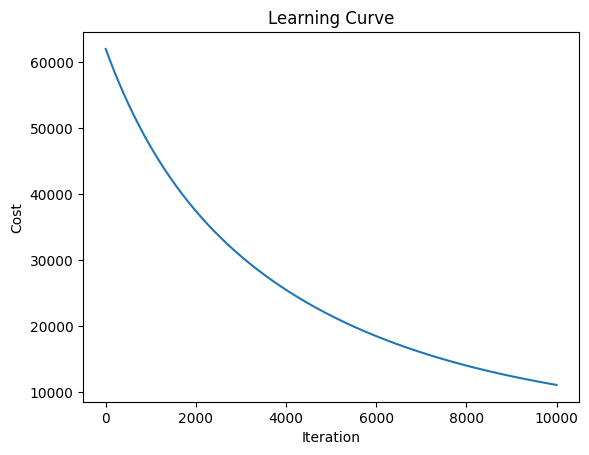

In [ ]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Learning Curve")
plt.show()


In [ ]:
predictions = regression(x_test, w_final, b_final)  # shape (m, 4)

# RMSE per output
rmse = np.sqrt(np.mean((predictions - y_test)**2, axis=0))

# R² per output
ss_res = np.sum((predictions - y_test)**2, axis=0)
ss_tot = np.sum((y_test - y_test.mean(axis=0))**2, axis=0)
r2 = 1 - (ss_res / ss_tot)

for i, name in enumerate(TARGETS):
    print(f"{name:12s} | RMSE: {rmse[i]:.4f} | R²: {r2[i]:.4f}")


CO(GT)       | RMSE: 0.9364 | R²: 0.5356
C6H6(GT)     | RMSE: 4.3682 | R²: 0.6348
NOx(GT)      | RMSE: 130.6045 | R²: 0.5492
NO2(GT)      | RMSE: 47.3643 | R²: -0.0536


In [ ]:
print("NO2(GT) std in y_train:", y_train[:, 3].std())
print("NO2(GT) mean in y_train:", y_train[:, 3].mean())

NO2(GT) std in y_train: 47.79473391795482
NO2(GT) mean in y_train: 114.12536023054756
